# Traffic Data Extraction for All Locations - 18 Hour Collection

This notebook collects **real-time traffic flow data** from TomTom Traffic API for all locations **every hour from 6 AM to 12 AM** (18 hours total).

## Data Collected:
- Current speed vs Free flow speed
- Traffic severity level
- Congestion ratio
- Speed reduction percentage
- Road closure status
- Travel time metrics
- Time label (6, 7, 8, ... 23 for hours)

## Collection Schedule:
- Start: 6 AM
- End: 12 AM (midnight)
- Frequency: Every 1 hour
- Total collections: 18

In [2]:
# Install and import required libraries
%pip install openpyxl

# Import Required Libraries
import requests
import pandas as pd
import numpy as np
import time
from datetime import datetime
import openpyxl


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for openpyxl from https://files.pythonhosted.org/packages/c0/da/977ded879c29cbd04de313843e76868e6e13408a94ed6b987245dc7c8506/openpyxl-3.1.5-py2.py3-none-any.whl.metadata
  Obtaining dependency information for et-xmlfile from https://files.pythonhosted.org/packages/c1/8b/5fe2cc11fee489817272089c4203e679c63b570a5aaeb18d852ae3cbba6a/et_xmlfile-2.0.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 250.9/250.9 kB 5.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Configuration
Set up TomTom Traffic API configuration

In [3]:
# TomTom API Configuration
API_KEY = "d5TWC3g2TRMlQr6VQvk0h5pfdQGrqCtA"
TRAFFIC_API_URL = "https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/17/json"

# API Parameters
API_PARAMS = {
    'unit': 'KMPH',          # Speed unit
    'thickness': 10,          # Segment width multiplier
    'openLr': False          # Don't include OpenLR code
}

print("✓ Configuration loaded")
print(f"  API Key: {API_KEY[:10]}...")
print(f"  Traffic API: {TRAFFIC_API_URL}")

✓ Configuration loaded
  API Key: d5TWC3g2TR...
  Traffic API: https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/17/json


## Load Locations Data
Load the 100 locations with coordinates from CSV

In [4]:
# Load locations from CSV
locations_df = pd.read_csv('100_locations_with_coords.csv')

# Display basic info
print(f"✓ Loaded {len(locations_df)} locations")
print(f"\nColumns: {list(locations_df.columns)}")
print(f"\nFirst 5 locations:")
print(locations_df.head())

# Check for missing coordinates
missing_coords = locations_df[locations_df['latitude'].isna() | locations_df['longitude'].isna()]
print(f"\n⚠️  Locations with missing coordinates: {len(missing_coords)}")
if len(missing_coords) > 0:
    print(missing_coords[['location_name']])

✓ Loaded 150 locations

Columns: ['location_name', 'latitude', 'longitude']

First 5 locations:
                         location_name   latitude  longitude
0  Mumbai Central, Mumbai, Maharashtra  18.977037  72.826266
1          CG Road, Ahmedabad, Gujarat  23.108360  72.586911
2               MG Road, Kochi, Kerala  10.516033  76.253846
3  Banjara Hills, Hyderabad, Telangana  17.409104  78.439467
4        Vastrapur, Ahmedabad, Gujarat  23.035083  72.527644

⚠️  Locations with missing coordinates: 0


## Traffic Data Fetching Function
Get real-time traffic flow data from TomTom Traffic API

In [5]:
def get_traffic_flow(lat, lon):
    """
    Fetch real-time traffic flow data from TomTom Traffic API
    
    Args:
        lat: Latitude
        lon: Longitude
    
    Returns:
        JSON response from API or None if error
    """
    # Prepare parameters
    params = {
        'key': API_KEY,
        'point': f'{lat},{lon}',  # Format: latitude,longitude
        **API_PARAMS
    }
    
    try:
        response = requests.get(TRAFFIC_API_URL, params=params)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"  ✗ API Error: {str(e)}")
        return None
    except Exception as e:
        print(f"  ✗ Unexpected Error: {str(e)}")
        return None

# Test with first location
if len(locations_df) > 0:
    test_loc = locations_df.iloc[0]
    print(f"Testing Traffic API with: {test_loc['location_name']}")
    print(f"Coordinates: ({test_loc['latitude']}, {test_loc['longitude']})")
    
    test_result = get_traffic_flow(test_loc['latitude'], test_loc['longitude'])
    
    if test_result:
        print(f"\n✓ API Test Successful!")
        if 'flowSegmentData' in test_result:
            flow_data = test_result['flowSegmentData']
            print(f"  Current Speed: {flow_data.get('currentSpeed', 'N/A')} km/h")
            print(f"  Free Flow Speed: {flow_data.get('freeFlowSpeed', 'N/A')} km/h")
            print(f"  Road Closure: {flow_data.get('roadClosure', 'N/A')}")
            print(f"  Confidence: {flow_data.get('confidence', 'N/A')}")

Testing Traffic API with: Mumbai Central, Mumbai, Maharashtra
Coordinates: (18.9770366, 72.826266)

✓ API Test Successful!
  Current Speed: 9 km/h
  Free Flow Speed: 14 km/h
  Road Closure: False
  Confidence: 0.9


## Traffic Severity Calculation
Calculate traffic severity and congestion metrics from flow data

In [ ]:
def calculate_traffic_severity(traffic_data):
    """
    Improved severity calculation using speed reduction + travel delay + congestion ratio
    """

    if not traffic_data or 'flowSegmentData' not in traffic_data:
        return {
            'severity': 'UNKNOWN',
            'congestion_ratio': 0,
            'speed_reduction': 0,
            'travel_delay_pct': 0,
            'current_speed': 0,
            'free_flow_speed': 0,
            'road_closure': False,
            'current_travel_time': 0,
            'free_flow_travel_time': 0,
            'confidence': 0,
            'frc': 'UNKNOWN'
        }

    fd = traffic_data["flowSegmentData"]
    current_speed = fd.get("currentSpeed", 0)
    free_flow_speed = fd.get("freeFlowSpeed", 1)
    road_closure = fd.get("roadClosure", False)

    current_tt = fd.get("currentTravelTime", 1)
    free_tt = fd.get("freeFlowTravelTime", 1)

    # Derived metrics
    congestion_ratio = current_speed / free_flow_speed
    speed_reduction = (1 - congestion_ratio) * 100            # % slowdown
    travel_delay_pct = ((current_tt - free_tt) / free_tt) * 100 if free_tt > 0 else 0

    # Composite score (0–3 scale)
    score = 0
    if speed_reduction > 20: score += 1
    if travel_delay_pct > 25: score += 1
    if congestion_ratio < 0.6: score += 1

    # Severity
    if road_closure:
        severity = "CLOSED"
    elif score == 0:
        severity = "LOW"
    elif score == 1:
        severity = "MODERATE"
    elif score == 2:
        severity = "HIGH"
    else:  # score = 3
        severity = "SEVERE"

    return {
        'severity': severity,
        'congestion_ratio': round(congestion_ratio, 2),
        'speed_reduction': round(speed_reduction, 2),
        'travel_delay_pct': round(travel_delay_pct, 2),
        'current_speed': current_speed,
        'free_flow_speed': free_flow_speed,
        'road_closure': road_closure,
        'current_travel_time': current_tt,
        'free_flow_travel_time': free_tt,
        'confidence': fd.get("confidence", 0),
        'frc': fd.get("frc", "UNKNOWN")
    }


: 

## Collect Traffic Data - 18 Hour Collection (6 AM to 12 AM)
Main data collection loop - collects traffic data every hour for 18 hours and saves to Excel

In [ ]:
def collect_18hour_traffic_data(locations_df, output_excel='traffic_data_18hr.csv', start_hour=6):
    """
    Collect real-time traffic data for all locations every hour for 18 hours (6 AM to 12 AM)
    
    Args:
        locations_df: DataFrame with location data
        output_excel: Output Excel filename (.xlsx)
        start_hour: Starting hour (default 6 for 6 AM)
    
    Returns:
        DataFrame with traffic data for all locations across 18 hours
    """
    import os
    
    # Initialize or load existing data from Excel
    if os.path.exists(output_excel):
        print(f"⚠️  File {output_excel} already exists. Loading existing data...")
        try:
            existing_df = pd.read_excel(output_excel, sheet_name='Traffic_Data')
            completed_hours = existing_df['hour_label'].unique().tolist()
            all_results = existing_df.to_dict('records')
            print(f"   Loaded {len(existing_df)} existing records")
            print(f"   Completed hours: {sorted(completed_hours)}")
        except Exception as e:
            print(f"   Error loading existing data: {str(e)}")
            all_results = []
            completed_hours = []
    else:
        all_results = []
        completed_hours = []
    
    print(f"\n🚀 Starting 18-hour traffic data collection")
    print(f"   Start hour: {start_hour} AM")
    print(f"   End hour: 12 AM (midnight)")
    print(f"   Output file: {output_excel}")
    print(f"   Total hours: 18 (6 AM to 12 AM)")
    print(f"=" * 80)
    
    # Collection time tracking
    collection_start = datetime.now()
    
    # Collect data for 18 hours (6 AM to 12 AM = hours 6 to 23)
    for hour_index in range(18):
        current_hour_label = (start_hour + hour_index) % 24
        
        # Skip if already collected
        if current_hour_label in completed_hours:
            print(f"\n⏭️  Hour {current_hour_label} already collected. Skipping...")
            continue
        
        print(f"\n{'='*80}")
        print(f"📊 HOUR {current_hour_label} ({hour_index + 1}/18)")
        print(f"   Collection started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"{'='*80}\n")
        
        hour_results = []
        locations_processed = 0
        locations_failed = 0
        api_error_detected = False
        
        # Collect data for all locations for this hour
        for idx, row in locations_df.iterrows():
            location_name = row['location_name']
            lat = row.get('latitude')
            lon = row.get('longitude')
            
            # Skip if no coordinates
            if pd.isna(lat) or pd.isna(lon):
                print(f"⚠️  [{idx+1}/{len(locations_df)}] Skipping {location_name} - no coordinates")
                locations_failed += 1
                continue
            
            print(f"🚗 [{idx+1}/{len(locations_df)}] {location_name}")
            
            try:
                # Fetch traffic data
                traffic_response = get_traffic_flow(lat, lon)
                
                # Check for None response (403 or other errors)
                if traffic_response is None:
                    print(f"\n{'='*80}")
                    print(f"🛑 CRITICAL ERROR: API request failed (possibly 403 Forbidden)")
                    print(f"   Stopping data collection for Hour {current_hour_label}")
                    print(f"   Previous hours' data is preserved in the Excel file")
                    print(f"   Please check your API key or quota")
                    print(f"{'='*80}")
                    api_error_detected = True
                    break
                
                # Check for API errors in response
                if 'detailedError' in traffic_response:
                    error_code = traffic_response['detailedError'].get('code', 'Unknown')
                    error_msg = traffic_response['detailedError'].get('message', 'Unknown error')
                    
                    print(f"\n{'='*80}")
                    print(f"🛑 API ERROR: {error_code} - {error_msg}")
                    print(f"   Stopping data collection for Hour {current_hour_label}")
                    print(f"   Previous hours' data is preserved")
                    print(f"{'='*80}")
                    api_error_detected = True
                    break
                
                # Calculate traffic metrics
                traffic_metrics = calculate_traffic_severity(traffic_response)
                
                # Prepare row data with hour label
                row_data = {
                    'hour_label': current_hour_label,
                    'location_name': location_name,
                    'latitude': lat,
                    'longitude': lon,
                    **traffic_metrics
                }
                
                hour_results.append(row_data)
                locations_processed += 1
                
                # Print summary
                print(f"   ✓ {traffic_metrics['severity']:8s} | "
                      f"Speed: {traffic_metrics['current_speed']:3.0f}/{traffic_metrics['free_flow_speed']:3.0f} km/h | "
                      f"Reduction: {traffic_metrics['speed_reduction']:5.1f}%")
                
                # Rate limiting
                time.sleep(0.5)
                
            except Exception as e:
                print(f"   ✗ Unexpected error: {str(e)}")
                locations_failed += 1
                continue
        
        # Handle API error - discard this hour's data and stop
        if api_error_detected:
            print(f"\n❌ Hour {current_hour_label} data DISCARDED due to API error")
            print(f"   {locations_processed} locations were processed before error")
            print(f"   Previous data is safe in: {output_excel}")
            print(f"\n🛑 Stopping collection. Please resolve API issues before continuing.")
            break
        
        # Add this hour's results to all results (IN MEMORY) - only if no errors
        if hour_results:
            all_results.extend(hour_results)
            
            # Now save the COMPLETE dataset to Excel
            try:
                # Create DataFrame with ALL accumulated data
                complete_df = pd.DataFrame(all_results)
                
                print(f"\n💾 Saving complete dataset to Excel...")
                print(f"   Records for hour {current_hour_label}: {len(hour_results)}")
                print(f"   Total records in memory: {len(complete_df)}")
                
                # Save to Excel with multiple sheets
                with pd.ExcelWriter(output_excel, engine='openpyxl', mode='w') as writer:
                    # Main data sheet - ALL DATA
                    complete_df.to_excel(writer, sheet_name='Traffic_Data', index=False)
                    
                    # Hour-wise summary
                    hourly_summary = complete_df.groupby('hour_label').agg({
                        'location_name': 'count',
                        'current_speed': 'mean',
                        'free_flow_speed': 'mean',
                        'speed_reduction': 'mean',
                        'congestion_ratio': 'mean'
                    }).round(2)
                    hourly_summary.columns = ['Records', 'Avg_Current_Speed', 'Avg_Free_Flow_Speed', 
                                               'Avg_Speed_Reduction', 'Avg_Congestion_Ratio']
                    hourly_summary.to_excel(writer, sheet_name='Hourly_Summary')
                    
                    # Severity distribution
                    severity_pivot = pd.crosstab(complete_df['hour_label'], complete_df['severity'])
                    severity_pivot.to_excel(writer, sheet_name='Severity_By_Hour')
                
                print(f"✅ Excel file saved successfully!")
                print(f"   Locations processed this hour: {locations_processed}/{len(locations_df)}")
                print(f"   Locations failed: {locations_failed}")
                print(f"   Total records in Excel file: {len(complete_df)}")
                print(f"   Hours completed: {sorted(complete_df['hour_label'].unique())}")
                
            except Exception as e:
                print(f"\n❌ Error saving data to Excel for hour {current_hour_label}: {str(e)}")
                import traceback
                traceback.print_exc()
        else:
            print(f"\n⚠️  No data collected for hour {current_hour_label}")
        
        # Wait for next hour (except for last iteration)
        if hour_index < 17 and not api_error_detected:
            next_hour = (current_hour_label + 1) % 24
            print(f"\n⏳ Waiting for next hour...")
            print(f"   Next collection: Hour {next_hour}")
            time.sleep(3600)  # Wait 1 hour
    
    # Final summary
    print(f"\n{'='*80}")
    if api_error_detected:
        print(f"⚠️  DATA COLLECTION STOPPED DUE TO API ERROR")
    else:
        print(f"✅ 18-HOUR DATA COLLECTION COMPLETE")
    print(f"{'='*80}")
    
    if os.path.exists(output_excel):
        final_df = pd.read_excel(output_excel, sheet_name='Traffic_Data')
        total_records = len(final_df)
        hours_collected = final_df['hour_label'].nunique()
        
        print(f"   Total records: {total_records}")
        print(f"   Hours collected: {hours_collected}/18")
        print(f"   Hours: {sorted(final_df['hour_label'].unique())}")
        print(f"   File: {output_excel}")
        print(f"   Collection time: {(datetime.now() - collection_start).total_seconds() / 3600:.1f} hours")
        
        if api_error_detected:
            print(f"\n⚠️  Note: Collection stopped early due to API error")
            print(f"   Data for completed hours is safely saved")
        
        return final_df
    else:
        print(f"   ⚠️  No data file created")
        return None

print("✓ 18-hour traffic data collection function ready")
print("⚠️  Run the next cell to start the 18-hour collection")

✓ 18-hour traffic data collection function ready
⚠️  Run the next cell to start the 18-hour collection


## RUN: Start 18-Hour Traffic Data Collection
Execute the 18-hour traffic data collection (6 AM to 12 AM) - saves to Excel

In [ ]:
# RUN THIS CELL TO START 18-HOUR TRAFFIC DATA COLLECTION
# This will run for 18 hours with 1-hour intervals and save to Excel (.xlsx)

# Define output filename with date
output_file = f'traffic_data_18hr.csv'

print(f"Starting 18-hour traffic data collection...")
print(f"Output file: {output_file} (Excel format)")
print(f"\n⚠️  IMPORTANT:")
print(f"   - This will run for approximately 18 hours")
print(f"   - Data is saved to Excel after each hour")
print(f"   - If interrupted, you can restart and it will skip completed hours")
print(f"   - If API quota is exceeded, collection will stop and save existing data")
print(f"   - Excel file includes multiple sheets: Traffic_Data, Hourly_Summary, Severity_By_Hour")
print(f"\nStarting in 5 seconds...")
time.sleep(5)

traffic_18hr_df = collect_18hour_traffic_data(
    locations_df=locations_df,
    output_excel=output_file,
    start_hour=6  # Start at 6 AM
)

# Display results
if traffic_18hr_df is not None:
    print("\n📊 Collected Traffic Data Summary:")
    print(f"   Total records: {len(traffic_18hr_df)}")
    print(f"   Hours covered: {sorted(traffic_18hr_df['hour_label'].unique())}")
    print(f"\nFirst 10 records:")
    print(traffic_18hr_df.head(10))

Starting 18-hour traffic data collection...
Output file: traffic_data_18hr.xlsx (Excel format)

⚠️  IMPORTANT:
   - This will run for approximately 18 hours
   - Data is saved to Excel after each hour
   - If interrupted, you can restart and it will skip completed hours
   - If API quota is exceeded, collection will stop and save existing data
   - Excel file includes multiple sheets: Traffic_Data, Hourly_Summary, Severity_By_Hour

Starting in 5 seconds...

🚀 Starting 18-hour traffic data collection
   Start hour: 6 AM
   End hour: 12 AM (midnight)
   Output file: traffic_data_18hr.xlsx
   Total hours: 18 (6 AM to 12 AM)

📊 HOUR 6 (1/18)
   Collection started at: 2025-11-27 05:51:28

🚗 [1/150] Mumbai Central, Mumbai, Maharashtra
   ✓ LOW      | Speed:  23/ 23 km/h | Reduction:   0.0%
🚗 [2/150] CG Road, Ahmedabad, Gujarat
   ✓ LOW      | Speed:  28/ 28 km/h | Reduction:   0.0%
🚗 [3/150] MG Road, Kochi, Kerala
   ✓ LOW      | Speed:  61/ 61 km/h | Reduction:   0.0%
🚗 [4/150] Banjara Hill

## Traffic Data Analysis & Summary
Analyze the collected 18-hour traffic data from Excel

In [ ]:
# Load the collected data from Excel
if 'traffic_18hr_df' not in locals():
    # Try to load from Excel file
    import glob
    files = glob.glob('traffic_data_18hr_*.xlsx')
    if files:
        latest_file = max(files)
        traffic_18hr_df = pd.read_excel(latest_file, sheet_name='Traffic_Data')
        print(f"Loaded data from Excel: {latest_file}")
    else:
        print("No traffic data Excel file found. Please run the collection first.")
        traffic_18hr_df = None

if traffic_18hr_df is not None:
    # Summary statistics
    print("📈 18-HOUR TRAFFIC DATA SUMMARY")
    print("="*80)
    
    # Overall statistics
    print(f"\nTotal records: {len(traffic_18hr_df)}")
    print(f"Total locations: {traffic_18hr_df['location_name'].nunique()}")
    print(f"Hours collected: {sorted(traffic_18hr_df['hour_label'].unique())}")
    
    # Records per hour
    print(f"\n📊 Records per Hour:")
    records_per_hour = traffic_18hr_df.groupby('hour_label').size().sort_index()
    for hour, count in records_per_hour.items():
        print(f"  Hour {hour:2d}: {count:3d} records")
    
    # Traffic severity distribution
    severity_counts = traffic_18hr_df['severity'].value_counts()
    print(f"\n🚦 Overall Traffic Severity Distribution:")
    for severity, count in severity_counts.items():
        percentage = (count / len(traffic_18hr_df)) * 100
        print(f"  {severity:10s}: {count:5d} records ({percentage:5.1f}%)")
    
    # Speed statistics by hour
    print(f"\n⚡ Average Speed by Hour:")
    speed_by_hour = traffic_18hr_df.groupby('hour_label').agg({
        'current_speed': 'mean',
        'free_flow_speed': 'mean',
        'speed_reduction': 'mean'
    }).round(1)
    print(speed_by_hour)
    
    # Peak congestion hours
    print(f"\n🔴 Peak Congestion Hours (by avg speed reduction):")
    peak_hours = speed_by_hour.nlargest(5, 'speed_reduction')
    for hour, row in peak_hours.iterrows():
        print(f"  Hour {hour:2d}: {row['speed_reduction']:5.1f}% reduction | "
              f"Speed: {row['current_speed']:.1f}/{row['free_flow_speed']:.1f} km/h")
    
    print("\n" + "="*80)

📈 18-HOUR TRAFFIC DATA SUMMARY

Total records: 894
Total locations: 150
Hours collected: [6, 7, 8, 9, 10, 11]

📊 Records per Hour:
  Hour  6: 150 records
  Hour  7: 150 records
  Hour  8: 150 records
  Hour  9: 150 records
  Hour 10: 150 records
  Hour 11: 144 records

🚦 Overall Traffic Severity Distribution:
  LOW       :   864 records ( 96.6%)
  CLOSED    :    24 records (  2.7%)
  MODERATE  :     6 records (  0.7%)

⚡ Average Speed by Hour:
            current_speed  free_flow_speed  speed_reduction
hour_label                                                 
6                    33.7             33.9              0.4
7                    33.8             33.9              0.4
8                    33.8             33.9              0.3
9                    33.8             33.9              0.3
10                   33.7             33.9              0.5
11                   34.2             34.4              0.4

🔴 Peak Congestion Hours (by avg speed reduction):
  Hour 10:   0.5% red

## Excel File Already Saved!
The Excel file is automatically saved during collection with multiple sheets

In [ ]:
if traffic_18hr_df is not None:
    # Find the latest Excel file
    import glob
    files = glob.glob('traffic_data_18hr_*.csv')
    if files:
        latest_file = max(files)
        
        print(f"✅ Traffic data is already saved in Excel format!")
        print(f"   File: {latest_file}")
        print(f"   Total records: {len(traffic_18hr_df)}")
        
        # Show sheet information
        excel_file = pd.ExcelFile(latest_file)
        print(f"\n📊 Excel file contains {len(excel_file.sheet_names)} sheets:")
        for sheet_name in excel_file.sheet_names:
            sheet_df = pd.read_excel(latest_file, sheet_name=sheet_name)
            print(f"   - {sheet_name}: {len(sheet_df)} rows × {len(sheet_df.columns)} columns")
        
        print(f"\n💡 You can open the file in Excel to view:")
        print(f"   - Sheet 'Traffic_Data': Complete 18-hour traffic data")
        print(f"   - Sheet 'Hourly_Summary': Statistics for each hour")
        print(f"   - Sheet 'Severity_By_Hour': Severity distribution by hour")
    else:
        print("⚠️  No Excel file found")

⚠️  No Excel file found


## Visualize Traffic Data
Optional: Create visualizations of the traffic data

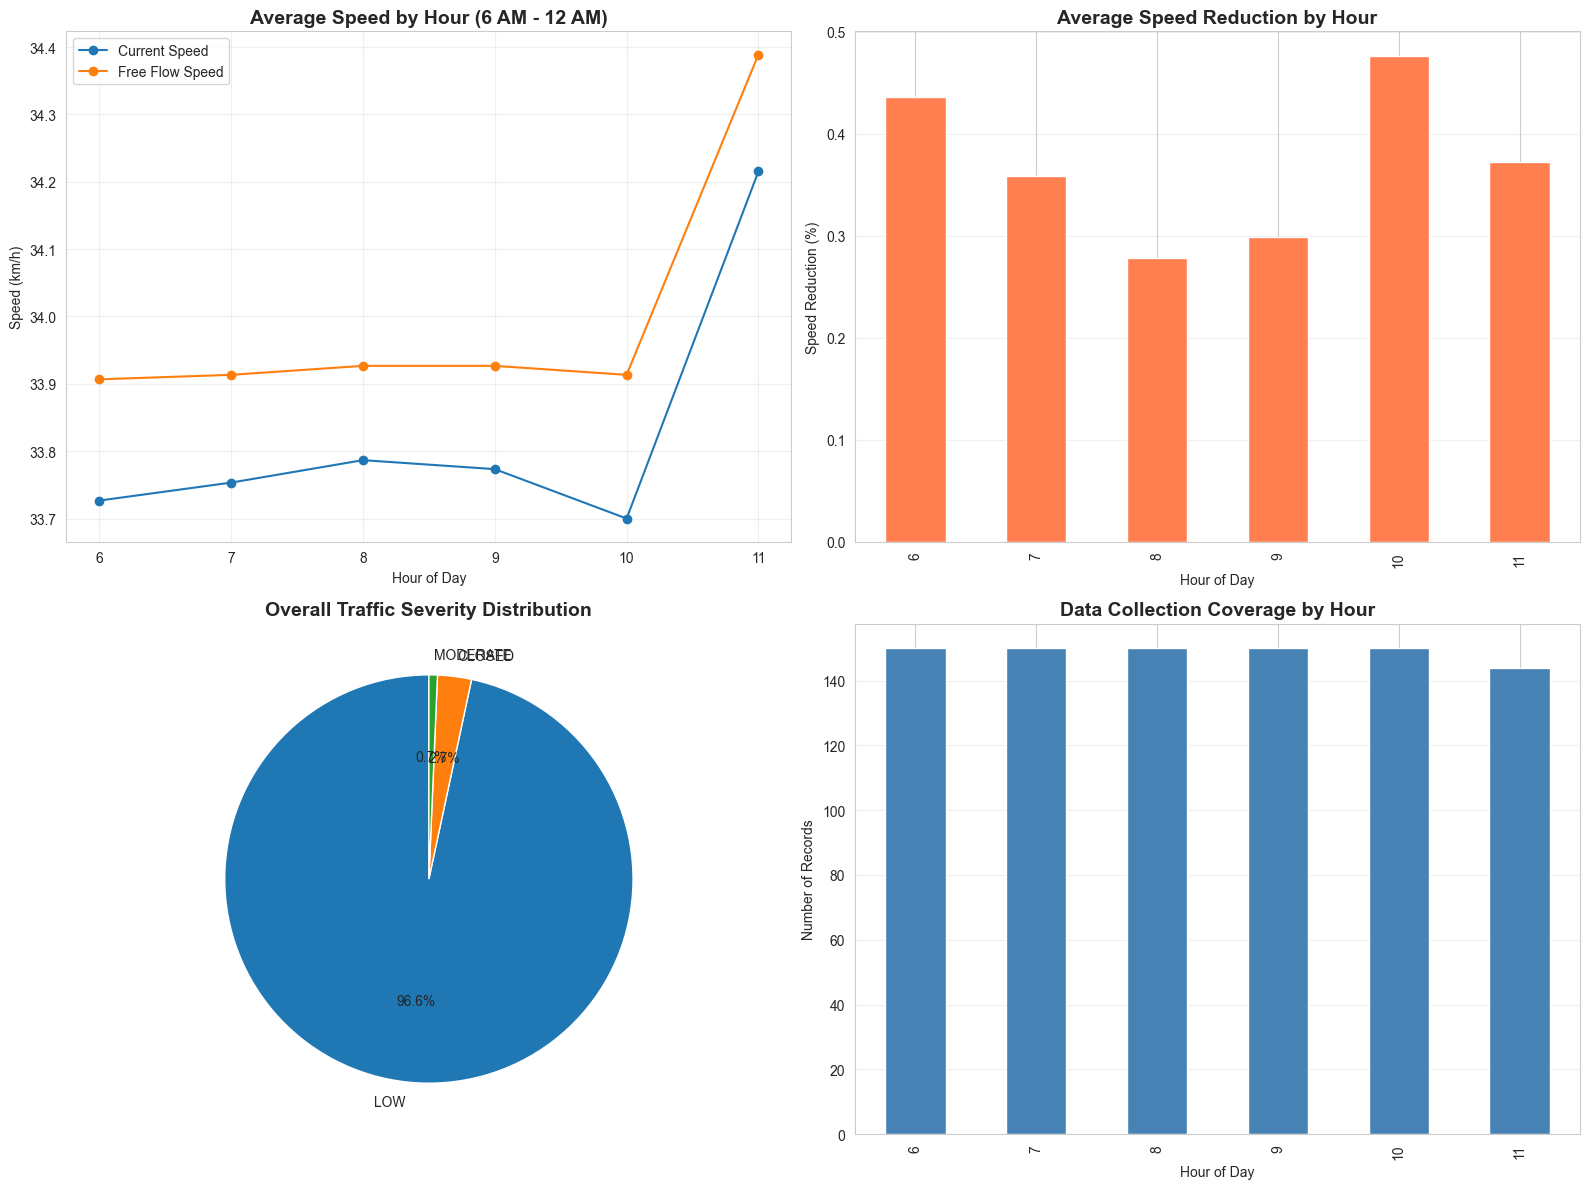

✓ Visualizations complete


In [ ]:
if traffic_18hr_df is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Average Speed by Hour
    ax1 = axes[0, 0]
    hourly_speeds = traffic_18hr_df.groupby('hour_label')[['current_speed', 'free_flow_speed']].mean()
    hourly_speeds.plot(ax=ax1, marker='o')
    ax1.set_title('Average Speed by Hour (6 AM - 12 AM)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Speed (km/h)')
    ax1.legend(['Current Speed', 'Free Flow Speed'])
    ax1.grid(alpha=0.3)
    
    # 2. Speed Reduction by Hour
    ax2 = axes[0, 1]
    hourly_reduction = traffic_18hr_df.groupby('hour_label')['speed_reduction'].mean()
    hourly_reduction.plot(kind='bar', ax=ax2, color='coral')
    ax2.set_title('Average Speed Reduction by Hour', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Speed Reduction (%)')
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Traffic Severity Distribution
    ax3 = axes[1, 0]
    severity_counts = traffic_18hr_df['severity'].value_counts()
    severity_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
    ax3.set_title('Overall Traffic Severity Distribution', fontsize=14, fontweight='bold')
    ax3.set_ylabel('')
    
    # 4. Records per Hour
    ax4 = axes[1, 1]
    records_per_hour = traffic_18hr_df.groupby('hour_label').size()
    records_per_hour.plot(kind='bar', ax=ax4, color='steelblue')
    ax4.set_title('Data Collection Coverage by Hour', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Hour of Day')
    ax4.set_ylabel('Number of Records')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Visualizations complete")

## Export Summary Statistics
Create a summary report

In [ ]:
if traffic_18hr_df is not None:
    # Create summary report
    summary_report = {
        'Collection Details': {
            'Total Records': len(traffic_18hr_df),
            'Total Locations': traffic_18hr_df['location_name'].nunique(),
            'Hours Collected': traffic_18hr_df['hour_label'].nunique(),
            'Date': datetime.now().strftime('%Y-%m-%d')
        },
        'Speed Metrics': {
            'Avg Current Speed': f"{traffic_18hr_df['current_speed'].mean():.1f} km/h",
            'Avg Free Flow Speed': f"{traffic_18hr_df['free_flow_speed'].mean():.1f} km/h",
            'Avg Congestion Ratio': f"{traffic_18hr_df['congestion_ratio'].mean():.2f}",
            'Avg Speed Reduction': f"{traffic_18hr_df['speed_reduction'].mean():.1f}%"
        },
        'Traffic Severity': traffic_18hr_df['severity'].value_counts().to_dict()
    }
    
    # Print summary report
    print("\n📋 TRAFFIC DATA COLLECTION SUMMARY REPORT")
    print("=" * 80)
    for section, data in summary_report.items():
        print(f"\n{section}:")
        for key, value in data.items():
            print(f"  {key}: {value}")
    print("=" * 80)
    
    # Save summary as JSON
    import json
    summary_filename = f'traffic_summary_18hr_{datetime.now().strftime("%Y%m%d")}.json'
    with open(summary_filename, 'w') as f:
        json.dump(summary_report, f, indent=2, default=str)
    
    print(f"\n✅ Summary report saved to: {summary_filename}")


📋 TRAFFIC DATA COLLECTION SUMMARY REPORT

Collection Details:
  Total Records: 894
  Total Locations: 150
  Hours Collected: 6
  Date: 2025-11-27

Speed Metrics:
  Avg Current Speed: 33.8 km/h
  Avg Free Flow Speed: 34.0 km/h
  Avg Congestion Ratio: 1.00
  Avg Speed Reduction: 0.4%

Traffic Severity:
  LOW: 864
  CLOSED: 24
  MODERATE: 6

✅ Summary report saved to: traffic_summary_18hr_20251127.json
